# Scikit-Learn: Clustering

**Topics covered:**
1. Introduction to Scikit-learn data format
2. K-Means clustering
3. Other clustering algorithms (DBSCAN, Agglomerative)
4. Internal evaluation: Silhouette score and Inertia (SSE)
5. Finding the optimal number of clusters
6. External evaluation: Adjusted Rand Score

In [50]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs

---
## 1. Scikit-learn data format

Scikit-learn models expect input data as a **2D NumPy array** (the features matrix):
- Rows represent samples
- Columns represent features

For **unsupervised** learning (e.g. clustering), only the features matrix is needed.

For **supervised** learning (e.g. regression, classification), a 1D target array is also required.

In [51]:
# Example features matrix: 3 samples, 3 features
X = np.array([
    [1.0,  5, 1.5],
    [1.4, 10, 0.3],
    [5.0,  8, 1.0]
])

print("Shape:", X.shape)  # (n_samples, n_features)

Shape: (3, 3)


In [52]:
# Categorical string values must be converted to integers before using Scikit-learn
# Example: 'January' -> 0, 'February' -> 1, 'March' -> 2

from sklearn.preprocessing import LabelEncoder

months = ['January', 'February', 'March', 'January']
le = LabelEncoder()
months_encoded = le.fit_transform(months)

print("Original:", months)
print("Encoded: ", months_encoded)

Original: ['January', 'February', 'March', 'January']
Encoded:  [1 0 2 1]


In [53]:
# Missing values (NaN) must also be handled before applying any model.
# Option 1: impute (fill in) missing values
# Option 2: remove rows containing missing values

from sklearn.impute import SimpleImputer

X_missing = np.array([
    [1.0, 0.5, 1.5],
    [1.4, np.nan, 0.3],
    [5.0, 0.5, 1.0]
])

# Replace NaN with the column mean
imputer = SimpleImputer(strategy='mean')
X_imputed = imputer.fit_transform(X_missing)

print("Before imputation:\n", X_missing)
print("After imputation:\n",  X_imputed)

Before imputation:
 [[1.  0.5 1.5]
 [1.4 nan 0.3]
 [5.  0.5 1. ]]
After imputation:
 [[1.  0.5 1.5]
 [1.4 0.5 0.3]
 [5.  0.5 1. ]]


All Scikit-learn models follow the same four-step pattern:

1. **Import** the model class
2. **Build** the model object, setting its hyperparameters
3. **Train** the model using `fit()`
4. **Use** the model with `predict()` or `transform()`

Some models combine steps 3 and 4 into a single method:
- `fit_predict()` - fit and assign cluster labels (clustering)
- `fit_transform()` - fit and transform data (e.g. PCA)

---
## 2. K-Means clustering

Clustering is an **unsupervised** technique: it finds structure in data without using any labels.

K-Means partitions data into **K clusters** by iteratively:
1. Assigning each point to its nearest centroid
2. Recomputing centroids as the mean of all assigned points

The main hyperparameter is `n_clusters` (K), which controls the number of clusters.

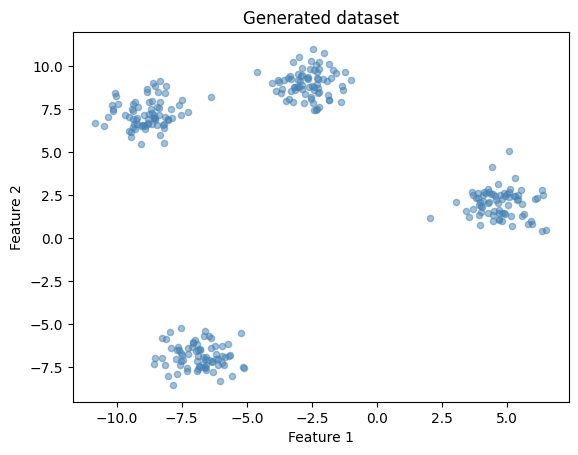

In [54]:
# Generate a synthetic dataset with 4 natural clusters
X, y_true = make_blobs(n_samples=300, centers=4, cluster_std=0.8, random_state=42)

plt.scatter(X[:, 0], X[:, 1], c='steelblue', alpha=0.5, s=20)
plt.title('Generated dataset')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.show()

In [55]:
from sklearn.cluster import KMeans

# Build the model: ask for 4 clusters
km = KMeans(n_clusters=4, random_state=42)

# fit_predict trains the model and returns the cluster label for each sample
y_pred = km.fit_predict(X)

print("Cluster labels (first 10):", y_pred[:10])
print("Unique labels:", np.unique(y_pred))

Cluster labels (first 10): [3 3 0 1 3 1 2 1 0 2]
Unique labels: [0 1 2 3]


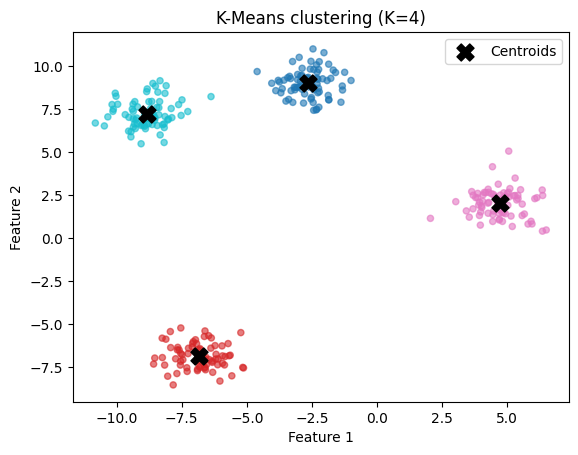

In [56]:
# Visualize the clustering result
plt.scatter(X[:, 0], X[:, 1], c=y_pred, cmap='tab10', alpha=0.6, s=20)
plt.scatter(km.cluster_centers_[:, 0], km.cluster_centers_[:, 1],
            c='black', marker='X', s=150, label='Centroids')
plt.title('K-Means clustering (K=4)')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.show()

In [57]:
# After fitting, learned parameters are stored as attributes ending with '_'
print("Cluster centers:\n", km.cluster_centers_)
print("Number of iterations:", km.n_iter_)

Cluster centers:
 [[-2.63715917  8.98563949]
 [-6.84180708 -6.84038791]
 [ 4.70253968  2.02807134]
 [-8.83330596  7.21790214]]
Number of iterations: 3


---
## 3. Other clustering algorithms

Scikit-learn provides many clustering algorithms. They all share the same interface.

**DBSCAN** (Density-Based Spatial Clustering of Applications with Noise):
- Groups points that are closely packed together
- Points in low-density regions are labeled as noise (-1)
- Does not require specifying the number of clusters in advance
- Key hyperparameters: `eps` (neighborhood radius), `min_samples` (minimum points to form a cluster)

**Agglomerative Clustering** (Hierarchical):
- Starts with each point as its own cluster and merges them bottom-up
- Requires specifying the number of clusters
- Key hyperparameter: `linkage` (how cluster distances are measured)

In [58]:
from sklearn.cluster import DBSCAN

# eps: max distance between two points to be considered neighbors
# min_samples: min number of neighbors to be a core point
dbscan = DBSCAN(eps=1.0, min_samples=5)
y_dbscan = dbscan.fit_predict(X)

print("Unique labels (including noise=-1):", np.unique(y_dbscan))
print("Number of noise points:", np.sum(y_dbscan == -1))

Unique labels (including noise=-1): [-1  0  1  2  3]
Number of noise points: 4


In [59]:
from sklearn.cluster import AgglomerativeClustering

# linkage='average' uses the average distance between all pairs of points in two clusters
agg = AgglomerativeClustering(n_clusters=4,  linkage='average',compute_full_tree=True)
y_agg = agg.fit_predict(X)

print("Unique labels:", np.unique(y_agg))

Unique labels: [0 1 2 3]


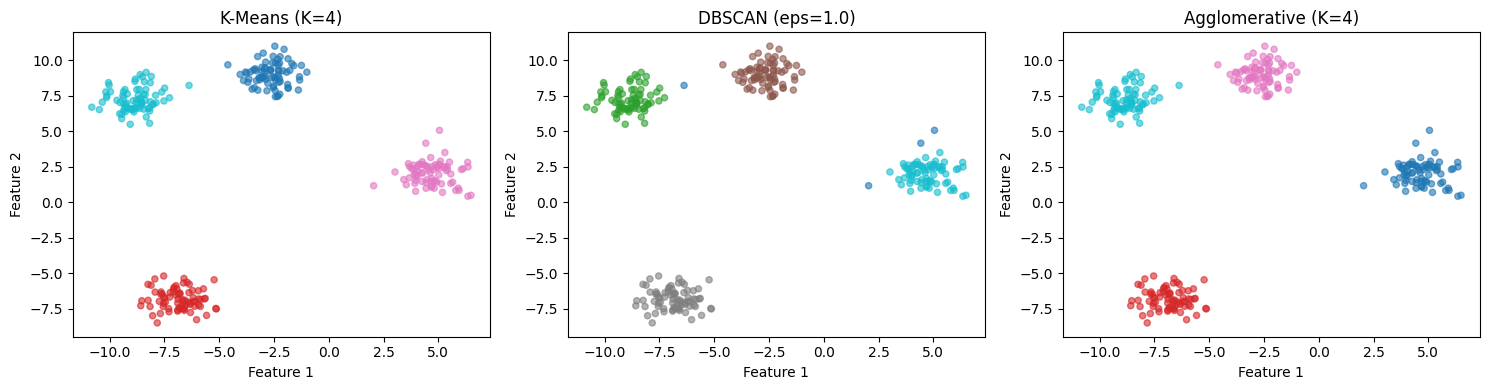

In [60]:
# Compare K-Means, DBSCAN, and Agglomerative on the same dataset
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

results = [
    ('K-Means (K=4)',         y_pred),
    ('DBSCAN (eps=1.0)',      y_dbscan),
    ('Agglomerative (K=4)',   y_agg),
]

for ax, (title, labels) in zip(axes, results):
    ax.scatter(X[:, 0], X[:, 1], c=labels, cmap='tab10', alpha=0.6, s=20)
    ax.set_title(title)
    ax.set_xlabel('Feature 1')
    ax.set_ylabel('Feature 2')

plt.tight_layout()
plt.show()

### Visualizing the dendrogram

Agglomerative clustering builds a hierarchy of merges. The **dendrogram** shows which clusters were merged at each step and at what distance. Cutting the tree horizontally at a given height gives the corresponding flat clustering.

In [61]:
from scipy.cluster.hierarchy import dendrogram, linkage

# scipy's linkage function computes the full merge tree.
# We use the same linkage method as AgglomerativeClustering above ('average').
rng    = np.random.RandomState(42)


Z = linkage(X, method='average')

In [62]:
# Z[:, 2] contains the merge distances in order.
# The best cut is where the jump between consecutive merges is largest.
merge_distances = Z[:, 2]
jumps = np.diff(merge_distances)

best_jump_idx  = np.argmax(jumps)
best_threshold = (merge_distances[best_jump_idx] + merge_distances[best_jump_idx + 1]) / 2
best_threshold

np.float64(9.446591722152235)

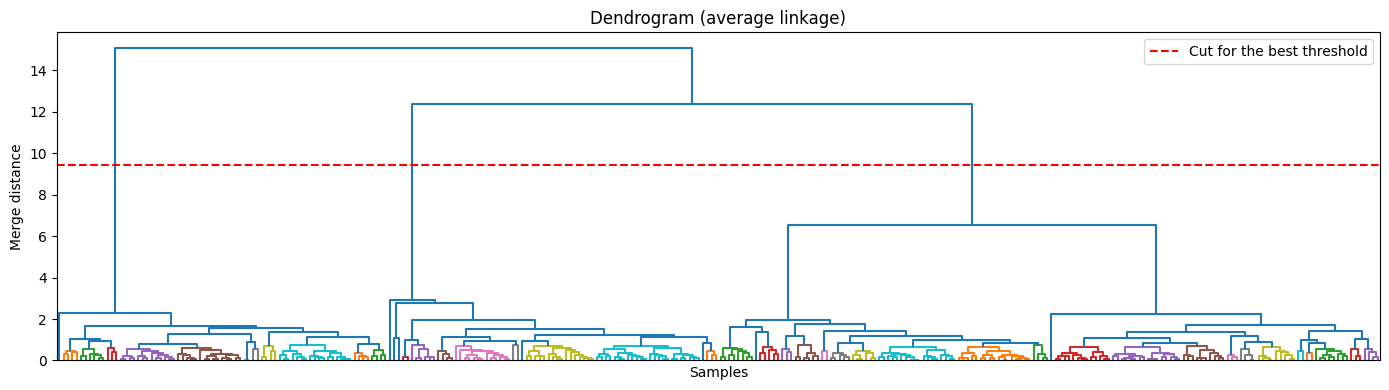

In [63]:
fig, ax = plt.subplots(figsize=(14, 4))
dendrogram(Z, ax=ax, no_labels=True, color_threshold=0.8)

# Draw a horizontal line to show where to cut for 3 clusters
ax.axhline(y=best_threshold, color='red', linestyle='--', label='Cut for the best threshold')

ax.set_title('Dendrogram (average linkage)')
ax.set_xlabel('Samples')
ax.set_ylabel('Merge distance')
ax.legend()
plt.tight_layout()
plt.show()

### Non-linearly separable data: concentric rings

Blobs are easy for any algorithm. A harder case is **concentric rings**, where clusters cannot be separated by a straight line or a convex region.

K-Means and Agglomerative (with Euclidean linkage) will fail here because they rely on distance to a centroid or average pairwise distance. DBSCAN can succeed because it looks at local density instead.

However, DBSCAN requires careful tuning of its two hyperparameters:
- `eps`: if too large, separate clusters get merged; if too small, points get classified as noise
- `min_samples`: if too large, even dense regions get treated as noise; if too small, noise points get absorbed into clusters

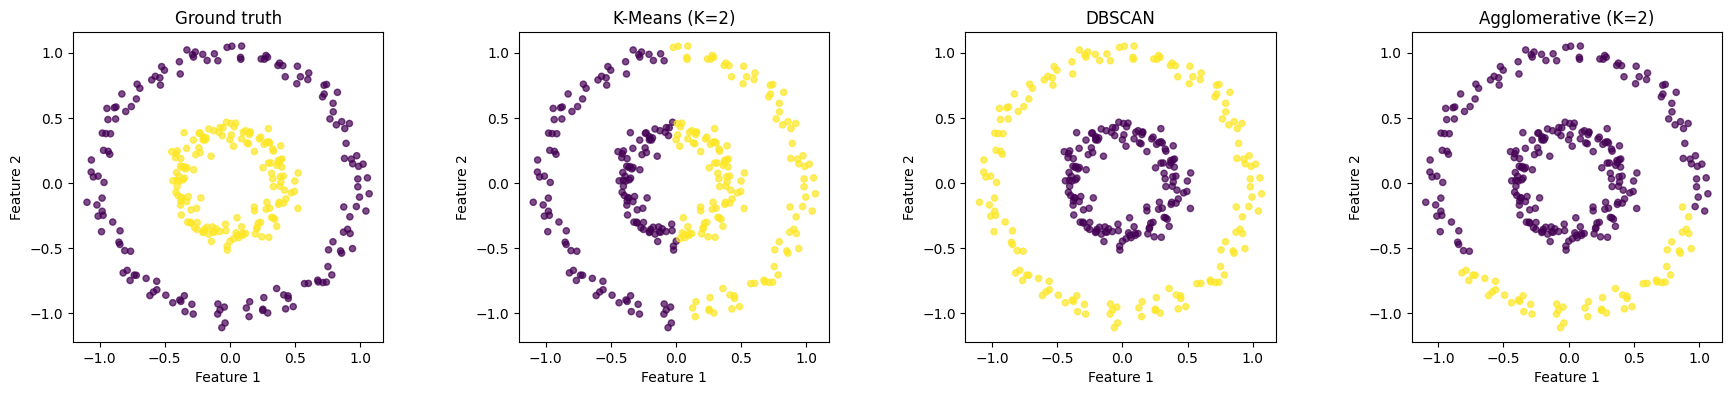

In [64]:
from sklearn.datasets import make_circles

# make_circles generates two concentric rings
# noise controls how much scatter is added to the points
# factor controls how far apart the two rings are
X_rings, y_rings_true = make_circles(n_samples=300, noise=0.05, factor=0.4, random_state=42)

# Fit the three algorithms on the ring dataset
km_rings    = KMeans(n_clusters=2, random_state=42)
dbscan_rings = DBSCAN(eps=0.25, min_samples=5) # if you vary eps, 
agg_rings   = AgglomerativeClustering(n_clusters=2, linkage='average')

y_km_rings    = km_rings.fit_predict(X_rings)
y_db_rings    = dbscan_rings.fit_predict(X_rings)
y_agg_rings   = agg_rings.fit_predict(X_rings)

fig, axes = plt.subplots(1, 4, figsize=(18, 4))

results_rings = [
    ('Ground truth',           y_rings_true),
    ('K-Means (K=2)',          y_km_rings),
    ('DBSCAN',      y_db_rings),
    ('Agglomerative (K=2)',    y_agg_rings),
]

for ax, (title, labels) in zip(axes, results_rings):
    ax.scatter(X_rings[:, 0], X_rings[:, 1], c=labels, cmap='viridis', alpha=0.7, s=20)
    ax.set_title(title)
    ax.set_xlabel('Feature 1')
    ax.set_ylabel('Feature 2')
    ax.set_aspect('equal')

plt.tight_layout()
plt.show()


---
## 4. Internal evaluation: Silhouette score and Inertia (SSE)

When ground-truth labels are unavailable, we use **internal metrics** that rely only on the features matrix.

**Silhouette score** for a single point $i$:

$$s(i) = \frac{b(i) - a(i)}{\max(b(i), a(i))}$$

where:
- $a(i)$: average distance from point $i$ to all other points in its cluster (cohesion)
- $b(i)$: smallest average distance from point $i$ to points in any other cluster (separation)

> `silhouette_score(X, labels)` returns the mean $s(i)$ over all samples, and is used to compare different clusterings or values of K. `silhouette_samples(X, labels)` returns the individual $s(i)$ for each point, useful to inspect which clusters are weak.

The score ranges from -1 to 1. Higher values mean better-defined clusters.

**Inertia (SSE)** is the sum of squared distances from each point to its cluster center:

$$SSE = \sum_{i=1}^{N} \|x_i - C(x_i)\|^2$$

Lower inertia means more compact clusters. 

**!! Note: Inertia always decreases as K increases $\rightarrow$ Search for the elbow**

In [65]:
from sklearn.cluster import KMeans

# Build the model: ask for 4 clusters
km = KMeans(n_clusters=4, random_state=42)

# fit_predict trains the model and returns the cluster label for each sample
y_pred = km.fit_predict(X)

print("Cluster labels (first 10):", y_pred[:10])
print("Unique labels:", np.unique(y_pred))

Cluster labels (first 10): [3 3 0 1 3 1 2 1 0 2]
Unique labels: [0 1 2 3]


In [66]:
from sklearn.metrics import silhouette_score, silhouette_samples

# silhouette_score returns the mean silhouette over all samples
silh_avg = silhouette_score(X, y_pred)
print(f"Mean silhouette score: {silh_avg:.4f}")

Mean silhouette score: 0.8335


In [67]:
# silhouette_samples returns the silhouette score for each individual sample
silh_per_sample = silhouette_samples(X, y_pred)

# Mean silhouette per cluster: useful for diagnosing individual cluster quality
for cluster_id in np.unique(y_pred):
    mask = y_pred == cluster_id
    mean_silh = silh_per_sample[mask].mean()
    print(f"Cluster {cluster_id}: mean silhouette = {mean_silh:.4f}")

Cluster 0: mean silhouette = 0.7930
Cluster 1: mean silhouette = 0.9024
Cluster 2: mean silhouette = 0.8585
Cluster 3: mean silhouette = 0.7801


In [68]:
# Inertia is stored as an attribute after fitting K-Means
print(f"Inertia (SSE): {km.inertia_:.2f}")

Inertia (SSE): 362.47


---
## 5. Finding the optimal number of clusters

Choosing K is one of the main challenges in clustering. Two complementary strategies:

**Elbow method** (Inertia): plot SSE vs K and look for the point where the curve bends sharply. Adding more clusters after that point gives diminishing returns.

**Silhouette method**: plot the mean silhouette score vs K and pick the K that maximizes it.

In [69]:
# Compute inertia and silhouette for a range of K values
k_values = range(2, 11)
inertias   = []
silhouettes = []

for k in k_values:
    km_k = KMeans(n_clusters=k, random_state=42)
    labels_k = km_k.fit_predict(X)
    inertias.append(km_k.inertia_)
    silhouettes.append(silhouette_score(X, labels_k))

print("Done computing scores for K = 2..10")

Done computing scores for K = 2..10


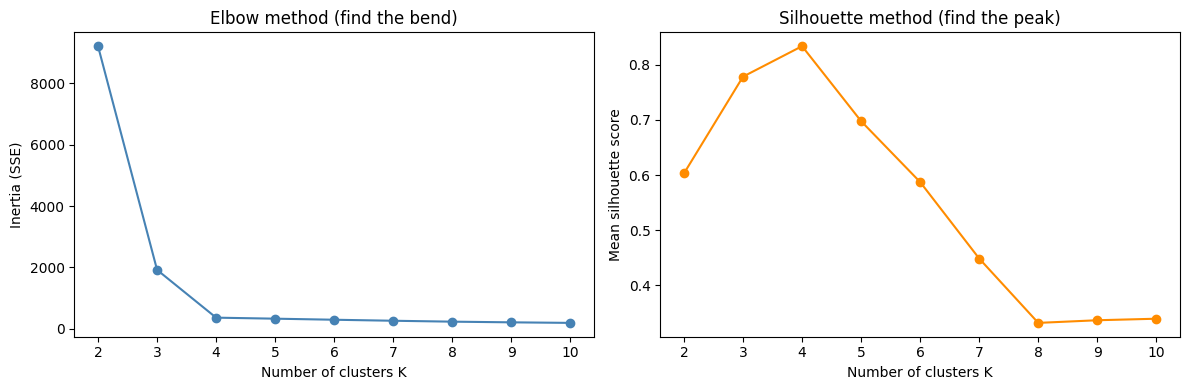

In [70]:
# Plot both curves side by side
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Elbow curve
axes[0].plot(list(k_values), inertias, marker='o', color='steelblue')
axes[0].set_title('Elbow method (find the bend)')
axes[0].set_xlabel('Number of clusters K')
axes[0].set_ylabel('Inertia (SSE)')

# Silhouette curve
axes[1].plot(list(k_values), silhouettes, marker='o', color='darkorange')
axes[1].set_title('Silhouette method (find the peak)')
axes[1].set_xlabel('Number of clusters K')
axes[1].set_ylabel('Mean silhouette score')

plt.tight_layout()
plt.show()

In [71]:
# Print the optimal K according to each criterion
best_k_silhouette = list(k_values)[np.argmax(silhouettes)]
print(f"Best K by silhouette:  {best_k_silhouette}  (score = {max(silhouettes):.4f})")

# For inertia, the elbow is identified visually (no automatic formula here)

Best K by silhouette:  4  (score = 0.8335)


---
## 6. External evaluation: Adjusted Rand Score

When ground-truth cluster labels are available, we can compare them against the predicted clusters using **external metrics**.

**Adjusted Rand Score (ARS)** measures how similarly two clusterings group the data:
- Score close to 1: clusterings agree
- Score close to 0: clusterings are no better than random
- Score below 0: clusterings are worse than random

Important: ARS does not require label names to match. It checks whether the same points are grouped together, not which integer label they were given.

In [72]:
from sklearn.metrics import adjusted_rand_score

# The true labels from make_blobs serve as ground truth
ars = adjusted_rand_score(y_true, y_pred)
print(f"Adjusted Rand Score (K-Means vs ground truth): {ars:.4f}")

Adjusted Rand Score (K-Means vs ground truth): 1.0000


In [73]:
# ARS checks grouping, not label equality.
# Swapping all label names does not change the score.
c_truth = np.array([1, 1, 2, 2, 2, 1])
c_pred  = np.array([2, 2, 1, 1, 1, 2])  # same grouping, different label names

score = adjusted_rand_score(c_truth, c_pred)
print(f"ARS when labels are swapped: {score:.4f}")

ARS when labels are swapped: 1.0000


In [74]:
# Compare all three algorithms against the ground truth
algorithms = [
    ('K-Means',        y_pred),
    ('DBSCAN',         y_dbscan),
    ('Agglomerative',  y_agg),
]

for name, labels in algorithms:
    # DBSCAN assigns -1 to noise points; ARS still handles them as a separate label
    score = adjusted_rand_score(y_true, labels)
    print(f"{name:20s} ARS = {score:.4f}")

K-Means              ARS = 1.0000
DBSCAN               ARS = 0.9823
Agglomerative        ARS = 1.0000


In [75]:
### Hyperparameter search for DBSCAN: ARI vs Silhouette

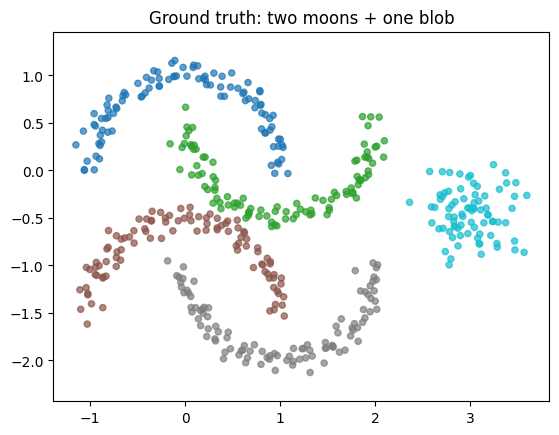

In [76]:
# A more complex dataset: two moons plus a separate blob, giving 3 natural clusters
from sklearn.datasets import make_moons

X_moons, y_moons = make_moons(n_samples=200, noise=0.07, random_state=42)

X2_moons, y2_moons = make_moons(n_samples=200, noise=0.07, random_state=0) 
X2_moons += [0, -1.5]  # shift the second moon down to create a new cluster
y2_moons+=2  # update labels to avoid overlap with the first moons

rng = np.random.RandomState(0)
X_blob = rng.randn(80, 2) * 0.25 + [3.0, -0.5]
y_blob = np.full(80, 4)

X_cx = np.vstack([X_moons, X2_moons, X_blob])
y_cx_true = np.concatenate([y_moons, y2_moons, y_blob])

plt.scatter(X_cx[:, 0], X_cx[:, 1], c=y_cx_true, cmap='tab10', s=20, alpha=0.7)
plt.title('Ground truth: two moons + one blob')
plt.axis('equal')
plt.show()

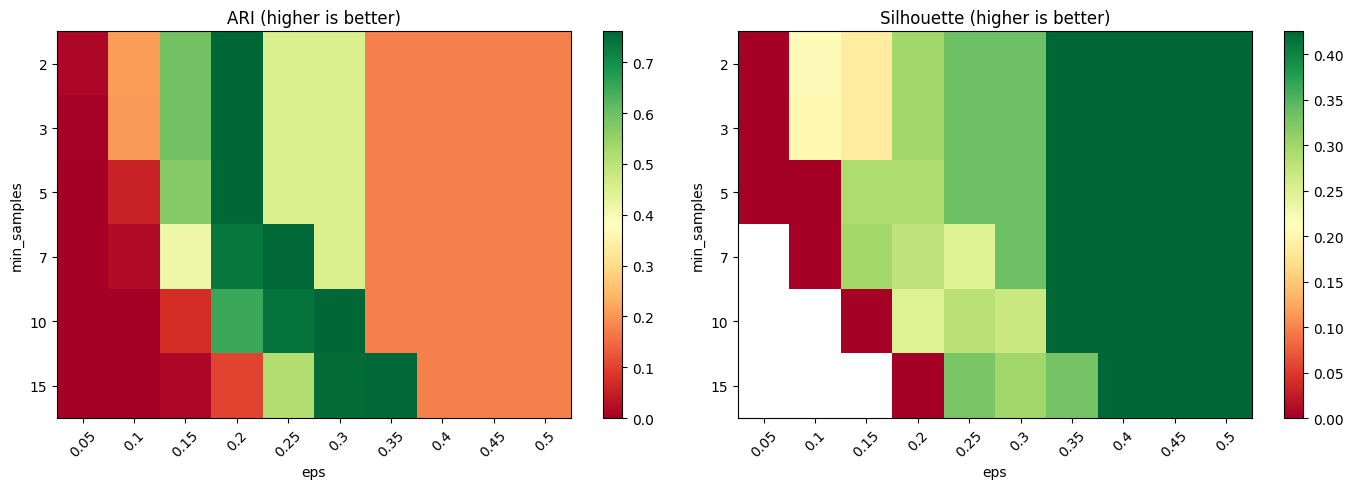

Best by ARI:       eps=0.2,  min_samples=2,  ARI=0.7606
Best by silhouette: eps=0.35, min_samples=2, silhouette=0.4251


In [77]:
# Grid search over eps and min_samples
# For each combination we record ARI and silhouette.
# Silhouette is undefined when DBSCAN finds fewer than 2 non-noise clusters,
# so we store NaN in those cases.

eps_values        = np.round(np.arange(0.05, 0.55, 0.05), 2)
min_samples_values = [2, 3, 5, 7, 10, 15]

ari_grid  = np.full((len(min_samples_values), len(eps_values)), np.nan)
silh_grid = np.full((len(min_samples_values), len(eps_values)), np.nan)

for i, ms in enumerate(min_samples_values):
    for j, ep in enumerate(eps_values):
        db     = DBSCAN(eps=ep, min_samples=ms)
        labels = db.fit_predict(X_cx)

        n_clusters = len(set(labels) - {-1})  # exclude noise label

        ari_grid[i, j] = adjusted_rand_score(y_cx_true, labels)

        if n_clusters >= 2:
            silh_grid[i, j] = silhouette_score(X_cx, labels)

# Plot both heatmaps side by side
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, grid, title in zip(axes,
                            [ari_grid, silh_grid],
                            ['ARI (higher is better)', 'Silhouette (higher is better)']):
    img = ax.imshow(grid, aspect='auto', cmap='RdYlGn', vmin=0)
    fig.colorbar(img, ax=ax)
    ax.set_xticks(range(len(eps_values)))
    ax.set_xticklabels(eps_values, rotation=45)
    ax.set_yticks(range(len(min_samples_values)))
    ax.set_yticklabels(min_samples_values)
    ax.set_xlabel('eps')
    ax.set_ylabel('min_samples')
    ax.set_title(title)

plt.tight_layout()
plt.show()

# Print the best combination according to each metric
best_ari  = np.unravel_index(np.nanargmax(ari_grid),  ari_grid.shape)
best_silh = np.unravel_index(np.nanargmax(silh_grid), silh_grid.shape)

print(f"Best by ARI:       eps={eps_values[best_ari[1]]},  min_samples={min_samples_values[best_ari[0]]},  ARI={ari_grid[best_ari]:.4f}")
print(f"Best by silhouette: eps={eps_values[best_silh[1]]}, min_samples={min_samples_values[best_silh[0]]}, silhouette={silh_grid[best_silh]:.4f}")

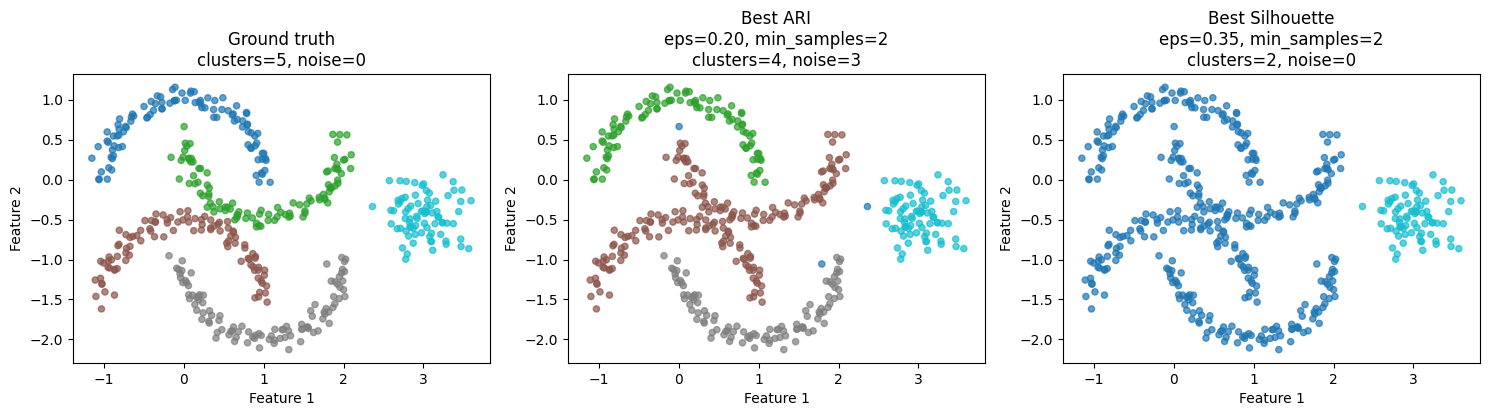

In [78]:
# Plot the clustering result for the two best parameter combinations
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

best_configs = [
    ('Ground truth',                      y_cx_true),
    ('Best ARI\neps=0.20, min_samples=2', DBSCAN(eps=0.20, min_samples=2).fit_predict(X_cx)),
    ('Best Silhouette\neps=0.35, min_samples=2', DBSCAN(eps=0.35, min_samples=2).fit_predict(X_cx)),
]

for ax, (title, labels) in zip(axes, best_configs):
    ax.scatter(X_cx[:, 0], X_cx[:, 1], c=labels, cmap='tab10', s=20, alpha=0.7)
    n_clusters = len(set(labels) - {-1})
    n_noise    = np.sum(labels == -1)
    ax.set_title(f'{title}\nclusters={n_clusters}, noise={n_noise}')
    ax.set_xlabel('Feature 1')
    ax.set_ylabel('Feature 2')
    ax.set_aspect('equal')

plt.tight_layout()
plt.show()

---
## Summary

| Concept | Key point |
|---|---|
| Features matrix | 2D NumPy array, shape (n_samples, n_features) |
| K-Means | Partitions data into K clusters; needs K in advance |
| DBSCAN | Density-based; finds noise points; K not required |
| Agglomerative | Hierarchical, bottom-up merging; needs K |
| Silhouette | Internal metric; range [-1, 1]; higher is better |
| Inertia (SSE) | Internal metric; lower is better; use the elbow method |
| Adjusted Rand Score | External metric; range ~ [0, 1]; needs ground truth |